In [1]:
import numpy as np
import graphical_sampling as gs
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.optimize import linear_sum_assignment

In [2]:
def plot_clusters_with_lines(coords, labels, centroids):

    coords = np.asarray(coords)
    k = centroids.shape[0]

    cmap = plt.cm.get_cmap("tab20", k)

    plt.figure(figsize=(8, 6))

    for c in range(k):

        idx = labels == c
        color = cmap(c)

        # plot points
        plt.scatter(
            coords[idx, 0],
            coords[idx, 1],
            color=color,
            s=30,
        )

        # draw lines to centroid
        for p in coords[idx]:
            plt.plot(
                [p[0], centroids[c, 0]],
                [p[1], centroids[c, 1]],
                color=color,
                linewidth=0.7,
                alpha=0.7
            )

        # plot centroid
        plt.scatter(
            centroids[c, 0],
            centroids[c, 1],
            color=color,
            marker="X",
            s=150,
            edgecolor="black"
        )

    plt.title("Balanced Clusters with Point‑to‑Centroid Connections")
    plt.xlabel("X")
    plt.ylabel("Y")
    # plt.axis("equal")
    plt.show()


In [3]:
class BalancedOTClustering:

    def __init__(
        self,
        n_clusters,
        batch_size=1024,
        greenkhorn_iters=50,
        epsilon_start=1.0,
        epsilon_end=0.02,
        epsilon_decay=0.995,
        beta_mass=0.1,
        lloyd_iters=3,
        random_state=None,
    ):

        self.K = n_clusters
        self.batch_size = batch_size
        self.greenkhorn_iters = greenkhorn_iters

        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

        self.beta_mass = beta_mass
        self.lloyd_iters = lloyd_iters

        self.rng = np.random.default_rng(random_state)

        self.centroids = None
        self.labels = None
        self.assignments = None

        self.u = None
        self.v = None
        self.global_mass = None

    # --------------------------------------------------

    def _cost(self, X):

        x2 = np.sum(X**2, axis=1, keepdims=True)
        m2 = np.sum(self.centroids**2, axis=1)

        return x2 + m2 - 2 * X @ self.centroids.T

    # --------------------------------------------------

    def _init_kmeanspp(self, X):

        N = X.shape[0]

        centroids = [X[self.rng.integers(N)]]

        for _ in range(1, self.K):

            dist2 = np.min(
                np.sum((X[:, None] - np.array(centroids)) ** 2, axis=2),
                axis=1,
            )

            p = dist2 / dist2.sum()

            centroids.append(X[self.rng.choice(N, p=p)])

        self.centroids = np.array(centroids)

    # --------------------------------------------------
    # Greenkhorn solver
    # --------------------------------------------------

    def _greenkhorn(self, C, a, b, eps):

        m, K = C.shape

        if self.u is None:
            self.u = np.zeros(m)

        if self.v is None:
            self.v = np.zeros(K)

        logK = -C / eps

        for _ in range(self.greenkhorn_iters):

            P = np.exp(self.u[:, None] + self.v[None, :] + logK)

            row_sum = P.sum(axis=1)
            col_sum = P.sum(axis=0)

            r_violation = row_sum - a
            c_violation = col_sum - b

            if np.max(np.abs(r_violation)) > np.max(np.abs(c_violation)):

                i = np.argmax(np.abs(r_violation))
                self.u[i] += np.log(a[i]) - np.log(row_sum[i] + 1e-12)

            else:

                j = np.argmax(np.abs(c_violation))
                self.v[j] += np.log(b[j]) - np.log(col_sum[j] + 1e-12)

        P = np.exp(self.u[:, None] + self.v[None, :] + logK)

        return P

    # --------------------------------------------------

    def _train(self, X, weights, iters=500):

        N = X.shape[0]

        self.global_mass = np.ones(self.K)

        eps = self.epsilon_start

        for _ in range(iters):

            idx = self.rng.choice(N, self.batch_size, replace=False)

            Xb = X[idx]
            wb = weights[idx]

            M = wb.sum()

            C = self._cost(Xb)

            a = wb

            b = np.ones(self.K) * (M / self.K)

            # global mass correction
            b -= self.beta_mass * (self.global_mass - 1)

            P = self._greenkhorn(C, a, b, eps)

            mass = P.sum(axis=0)

            self.global_mass = 0.9 * self.global_mass + 0.1 * mass

            new_centroids = (P.T @ Xb) / (mass[:, None] + 1e-12)

            lr = 0.5
            self.centroids = (1 - lr) * self.centroids + lr * new_centroids

            eps = max(self.epsilon_end, eps * self.epsilon_decay)

    # --------------------------------------------------
    # full OT refinement
    # --------------------------------------------------

    def _full_ot(self, X, weights):

        C = self._cost(X)

        eps = self.epsilon_end

        logK = -C / eps

        u = np.zeros(X.shape[0])
        v = np.zeros(self.K)

        a = weights
        b = np.ones(self.K) * (weights.sum() / self.K)

        for _ in range(200):

            u = np.log(a) - logsumexp(logK + v[None, :], axis=1)
            v = np.log(b) - logsumexp(logK.T + u[None, :], axis=1)

        P = np.exp(u[:, None] + v[None, :] + logK)

        return P

    # --------------------------------------------------
    # optimal balanced assignment
    # --------------------------------------------------

    def _balanced_assignment(self, C):

        N = C.shape[0]
        cap = N // self.K

        expanded = np.repeat(np.arange(self.K), cap)

        cost = C[:, expanded]

        r, c = linear_sum_assignment(cost)

        labels = expanded[c]

        return labels

    # --------------------------------------------------
    # Lloyd refinement
    # --------------------------------------------------

    def _lloyd(self, X):

        for _ in range(self.lloyd_iters):

            for k in range(self.K):

                pts = X[self.labels == k]

                if len(pts) > 0:
                    self.centroids[k] = pts.mean(axis=0)

            C = self._cost(X)

            self.labels = self._balanced_assignment(C)

    # --------------------------------------------------

    def fit(self, X, weights=None):

        N = X.shape[0]

        if weights is None:
            weights = np.ones(N)

        weights = weights.astype(float)
        weights *= self.K / weights.sum()

        self._init_kmeanspp(X)

        self._train(X, weights)

        P = self._full_ot(X, weights)

        self.assignments = P

        C = self._cost(X)

        self.labels = self._balanced_assignment(C)

        self._lloyd(X)

        return self

    # --------------------------------------------------

    def predict(self, X):

        C = (
            np.sum(X**2, axis=1, keepdims=True)
            + np.sum(self.centroids**2, axis=1)
            - 2 * X @ self.centroids.T
        )

        return np.argmin(C, axis=1)


In [9]:
import numpy as np
from sklearn.metrics import pairwise_distances


class BalancedSoftKMeansLogBarrier:

    def __init__(self, n_clusters, lambda1=100, lambda2=1.0,
                 max_iter=100, tol=1e-4, random_state=None):

        self.K = n_clusters
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state


    def _softmax(self, x):
        x = x - x.max(axis=1, keepdims=True)
        e = np.exp(x)
        return e / e.sum(axis=1, keepdims=True)


    def fit(self, X, pi):

        rng = np.random.default_rng(self.random_state)

        N, D = X.shape
        K = self.K

        # initialize centroids
        idx = rng.choice(N, K, replace=False)
        mu = X[idx].copy()

        # initialize assignments
        r = rng.random((N, K))
        r /= r.sum(axis=1, keepdims=True)

        eps = 1e-12

        for it in range(self.max_iter):

            mu_old = mu.copy()

            # pairwise squared distances
            d = pairwise_distances(X, mu, metric="sqeuclidean")

            # cluster masses
            T = (pi[:, None] * r).sum(axis=0)

            # update assignments point-by-point
            for n in range(N):

                # remove current contribution
                T -= pi[n] * r[n]

                T_safe = T + eps

                score_balance = (self.lambda1 * pi[n]) / (self.lambda2 * T_safe)
                score_dist = -d[n] / self.lambda2

                s = score_dist + score_balance

                s = s - s.max()
                rn = np.exp(s)
                rn /= rn.sum()

                r[n] = rn

                # add updated contribution
                T += pi[n] * r[n]

            # update centroids
            weights = r.sum(axis=0) + eps
            mu = (r.T @ X) / weights[:, None]

            # convergence check
            shift = np.linalg.norm(mu - mu_old)
            if shift < self.tol:
                break

        self.centroids = mu
        self.assignments = r
        self.labels = r.argmax(axis=1)

        return self


In [4]:
N = 400
n = 10
rng = gs.random.rng()
coords = rng.rand_coord((N, 2))
# inclusions = rng.equal_inclusions(n, N)
inclusions = rng.unequal_inclusions(n, N)
pop = gs.Population(coords, inclusions, n=n)

In [16]:
model = BalancedOTClustering(
    n_clusters=n,
    batch_size=128,
    random_state=42,
)

model.fit(pop.coords, pop.inclusions)

In [17]:
deviation = 0
for i in range(n):
    hard = float(pop.inclusions[model.labels == i].sum())
    soft = float(model.assignments[:, i].sum())
    deviation += abs(hard - 1)
    print(f'Cluster {i+1}: soft={soft:.4f} - hard={hard:.4f}')
print(f'\nTotal Deviation of Hard: {deviation:.4f}')

Cluster 1: soft=1.0000 - hard=1.0229
Cluster 2: soft=1.0000 - hard=0.9997
Cluster 3: soft=1.0000 - hard=0.9317
Cluster 4: soft=1.0000 - hard=0.9854
Cluster 5: soft=1.0000 - hard=1.0965
Cluster 6: soft=1.0000 - hard=1.0136
Cluster 7: soft=1.0000 - hard=1.0485
Cluster 8: soft=1.0000 - hard=0.8051
Cluster 9: soft=1.0000 - hard=1.0679
Cluster 10: soft=1.0000 - hard=0.9394
Cluster 11: soft=1.0000 - hard=0.9903
Cluster 12: soft=1.0000 - hard=1.0435
Cluster 13: soft=1.0000 - hard=0.9871
Cluster 14: soft=1.0000 - hard=0.9219
Cluster 15: soft=1.0000 - hard=1.0274
Cluster 16: soft=1.0000 - hard=1.0832
Cluster 17: soft=1.0000 - hard=0.9156
Cluster 18: soft=1.0000 - hard=0.9680
Cluster 19: soft=1.0000 - hard=1.1051
Cluster 20: soft=1.0000 - hard=1.0472

Total Deviation of Hard: 1.1113


/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T/ipykernel_1270/1218941298.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", k)


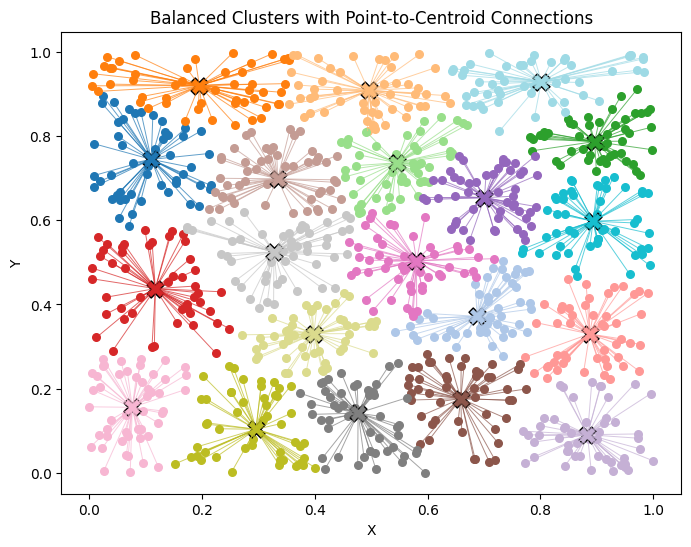

In [18]:
plot_clusters_with_lines(coords, model.labels, model.centroids)

In [19]:
model = BalancedSoftKMeansLogBarrier(
    n_clusters=n,
    lambda1=5.1607,
    lambda2=0.0121
)

model.fit(pop.coords, pop.inclusions)

In [20]:
deviation = 0
for i in range(n):
    hard = float(pop.inclusions[model.labels == i].sum())
    p = model.assignments[:, i] * pop.inclusions
    soft = float(p.sum())
    deviation += abs(hard - 1)
    print(f'Cluster {i+1}: soft={soft:4f} - hard={hard:4f}')

print(f'\nTotal Deviation of Hard: {deviation:.4f}')

Cluster 1: soft=0.979069 - hard=0.893234
Cluster 2: soft=1.009421 - hard=1.049531
Cluster 3: soft=0.991993 - hard=0.971860
Cluster 4: soft=1.007826 - hard=1.013989
Cluster 5: soft=1.000819 - hard=0.909774
Cluster 6: soft=1.005683 - hard=1.072704
Cluster 7: soft=0.968956 - hard=0.965733
Cluster 8: soft=1.004315 - hard=0.994815
Cluster 9: soft=0.997498 - hard=1.108572
Cluster 10: soft=1.007958 - hard=1.077290
Cluster 11: soft=0.992672 - hard=0.974270
Cluster 12: soft=1.021054 - hard=1.091767
Cluster 13: soft=0.994060 - hard=0.952491
Cluster 14: soft=1.002244 - hard=1.019313
Cluster 15: soft=1.025745 - hard=1.073668
Cluster 16: soft=1.025302 - hard=1.133312
Cluster 17: soft=0.971214 - hard=0.887633
Cluster 18: soft=1.004791 - hard=0.983480
Cluster 19: soft=0.993009 - hard=0.944238
Cluster 20: soft=0.996370 - hard=0.882327

Total Deviation of Hard: 1.2803


/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T/ipykernel_1270/1218941298.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", k)


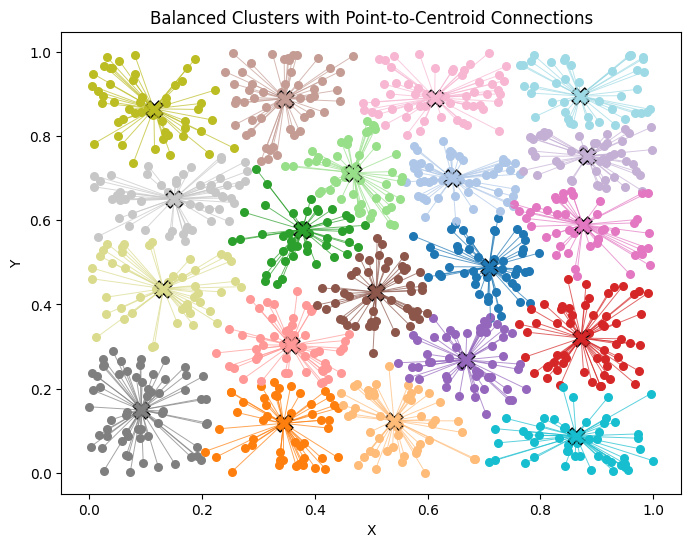

In [21]:
plot_clusters_with_lines(coords, model.labels, model.centroids)

In [55]:
from tqdm import tqdm

def evaluate_lambda_grid(
        X,
        pi,
        K,
        lambda1_range=(0, 50),
        lambda2_range=(0.01, 5),
        n_lambda1=20,
        n_lambda2=20,
        max_iter=50,
        random_state=0
):

    lambda1_vals = np.linspace(*lambda1_range, n_lambda1)
    lambda2_vals = np.linspace(*lambda2_range, n_lambda2)

    soft_dev = np.zeros((n_lambda1, n_lambda2))
    hard_dev = np.zeros((n_lambda1, n_lambda2))

    results = []

    for i, l1 in enumerate(tqdm(lambda1_vals)):
        for j, l2 in enumerate(lambda2_vals):

            model = BalancedSoftKMeansLogBarrier(
                n_clusters=K,
                lambda1=l1,
                lambda2=l2,
                max_iter=max_iter,
            )

            model.fit(X, pi)

            r = model.assignments
            labels = model.labels

            # ----- soft masses -----
            T = (r * pi[:, None]).sum(axis=0)
            s_dev = np.sum(np.abs(T - 1))

            # ----- hard masses -----
            H = np.zeros(K)
            for k in range(K):
                H[k] = pi[labels == k].sum()

            h_dev = np.sum(np.abs(H - 1))

            soft_dev[i, j] = s_dev
            hard_dev[i, j] = h_dev

            results.append((l1, l2, s_dev, h_dev))

            # print(f"λ1={l1:.3f} λ2={l2:.3f} | soft={s_dev:.4f} hard={h_dev:.4f}")

    # ------------------------
    # plot heatmaps
    # ------------------------

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    im0 = ax[0].imshow(
        soft_dev,
        origin="lower",
        aspect="auto",
        extent=[lambda2_vals[0], lambda2_vals[-1],
                lambda1_vals[0], lambda1_vals[-1]]
    )

    ax[0].set_title("Soft balance deviation")
    ax[0].set_xlabel("lambda_2")
    ax[0].set_ylabel("lambda_1")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(
        hard_dev,
        origin="lower",
        aspect="auto",
        extent=[lambda2_vals[0], lambda2_vals[-1],
                lambda1_vals[0], lambda1_vals[-1]]
    )

    ax[1].set_title("Hard balance deviation")
    ax[1].set_xlabel("lambda_2")
    ax[1].set_ylabel("lambda_1")
    plt.colorbar(im1, ax=ax[1])

    plt.tight_layout()
    plt.show()

    # ------------------------
    # print best 10
    # ------------------------

    results.sort(key=lambda x: x[2])

    print("\nTop 5 parameter combinations (best soft balance):")

    for r in results[:5]:
        print(
            f"lambda1={r[0]:.4f}  lambda2={r[1]:.4f}  "
            f"soft_dev={r[2]:.6f}  hard_dev={r[3]:.6f}"
        )

    results.sort(key=lambda x: x[3])

    print("\nTop 5 parameter combinations (best hard balance):")

    for r in results[:5]:
        print(
            f"lambda1={r[0]:.4f}  lambda2={r[1]:.4f}  "
            f"soft_dev={r[2]:.6f}  hard_dev={r[3]:.6f}"
        )

    results.sort(key=lambda x: (x[2]+x[3])/2)

    print("\nTop 5 parameter combinations (best combined):")

    for r in results[:5]:
        print(
            f"lambda1={r[0]:.4f}  lambda2={r[1]:.4f}  "
            f"soft_dev={r[2]:.6f}  hard_dev={r[3]:.6f}"
        )

    return soft_dev, hard_dev, lambda1_vals, lambda2_vals


100%|██████████| 20/20 [00:55<00:00,  2.76s/it]


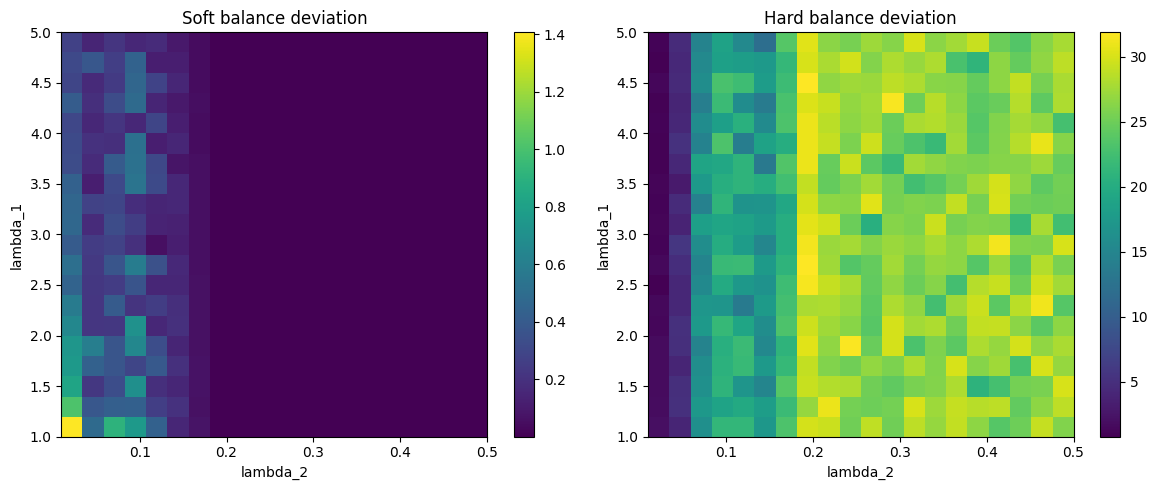


Top 5 parameter combinations (best soft balance):
lambda1=5.0000  lambda2=0.4742  soft_dev=0.000002  hard_dev=26.342201
lambda1=3.3158  lambda2=0.4742  soft_dev=0.000002  hard_dev=24.913706
lambda1=4.1579  lambda2=0.4742  soft_dev=0.000002  hard_dev=26.792245
lambda1=3.9474  lambda2=0.4742  soft_dev=0.000002  hard_dev=30.834334
lambda1=3.7368  lambda2=0.4742  soft_dev=0.000002  hard_dev=27.285597

Top 5 parameter combinations (best hard balance):
lambda1=4.7895  lambda2=0.0100  soft_dev=0.311355  hard_dev=0.765389
lambda1=2.4737  lambda2=0.0100  soft_dev=0.448345  hard_dev=0.794812
lambda1=3.9474  lambda2=0.0100  soft_dev=0.314753  hard_dev=0.935438
lambda1=4.3684  lambda2=0.0100  soft_dev=0.406870  hard_dev=0.973387
lambda1=3.7368  lambda2=0.0100  soft_dev=0.325967  hard_dev=1.003720

Top 5 parameter combinations (best combined):
lambda1=4.7895  lambda2=0.0100  soft_dev=0.311355  hard_dev=0.765389
lambda1=2.4737  lambda2=0.0100  soft_dev=0.448345  hard_dev=0.794812
lambda1=3.9474  la

(array([[1.40733202e+00, 4.85728588e-01, 9.07559989e-01, 7.58336721e-01,
         4.37374007e-01, 1.50991754e-01, 7.65209207e-02, 7.21709880e-04,
         6.51984238e-05, 3.78710042e-05, 3.11555931e-05, 2.37610982e-05,
         1.30406096e-05, 1.18634516e-05, 8.81504431e-06, 9.34692625e-06,
         1.07744814e-05, 6.73088358e-06, 3.73553098e-06, 4.79392784e-06],
        [1.01178416e+00, 3.82046185e-01, 4.25722187e-01, 4.34064204e-01,
         2.58623670e-01, 2.01196110e-01, 6.30230257e-02, 7.62839795e-04,
         6.70920902e-05, 3.81065951e-05, 2.79477447e-05, 2.13372453e-05,
         1.83727551e-05, 1.47984947e-05, 1.03735026e-05, 1.05574663e-05,
         4.63958252e-06, 6.29200636e-06, 4.02121705e-06, 6.00100283e-06],
        [8.19636875e-01, 2.27437496e-01, 3.35104587e-01, 7.02934821e-01,
         1.87258978e-01, 1.53548078e-01, 6.90594919e-02, 7.34665182e-04,
         6.20513433e-05, 3.45580435e-05, 2.63328618e-05, 1.34243899e-05,
         1.71577530e-05, 1.32821633e-05, 1.102855

In [90]:
evaluate_lambda_grid(
    pop.coords,
    pop.inclusions,
    K=n,
    lambda1_range=(1.0, 5.0),
    lambda2_range=(0.01, 0.5),
    n_lambda1=20,
    n_lambda2=20,
    random_state=42
)

In [95]:
from tqdm import tqdm

def evaluate_lambda_grid2(
        X,
        pi,
        K,
        alpha_range=(0, 50),
        lambda2_range=(0.01, 5),
        n_alpha=20,
        n_lambda2=20,
        max_iter=50,
        random_state=0
):

    alpha_vals = np.linspace(*alpha_range, n_alpha)
    lambda2_vals = np.linspace(*lambda2_range, n_lambda2)

    soft_dev = np.zeros((n_alpha, n_lambda2))
    hard_dev = np.zeros((n_alpha, n_lambda2))

    results = []

    for i, alpha in enumerate(tqdm(alpha_vals)):
        for j, l2 in enumerate(lambda2_vals):

            l1 = alpha * l2

            model = BalancedSoftKMeansLogBarrier(
                n_clusters=K,
                lambda1=l1,
                lambda2=l2,
                max_iter=max_iter,
            )

            model.fit(X, pi)

            r = model.assignments
            labels = model.labels

            # ----- soft masses -----
            T = (r * pi[:, None]).sum(axis=0)
            s_dev = np.sum(np.abs(T - 1))

            # ----- hard masses -----
            H = np.zeros(K)
            for k in range(K):
                H[k] = pi[labels == k].sum()

            h_dev = np.sum(np.abs(H - 1))

            soft_dev[i, j] = s_dev
            hard_dev[i, j] = h_dev

            results.append((l1, l2, s_dev, h_dev))

            # print(f"λ1={l1:.3f} λ2={l2:.3f} | soft={s_dev:.4f} hard={h_dev:.4f}")

    # ------------------------
    # plot heatmaps
    # ------------------------

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    im0 = ax[0].imshow(
        soft_dev,
        origin="lower",
        aspect="auto",
        extent=[lambda2_vals[0], lambda2_vals[-1],
                alpha_vals[0], alpha_vals[-1]]
    )

    ax[0].set_title("Soft balance deviation")
    ax[0].set_xlabel("lambda_2")
    ax[0].set_ylabel("lambda_1")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(
        hard_dev,
        origin="lower",
        aspect="auto",
        extent=[lambda2_vals[0], lambda2_vals[-1],
                alpha_vals[0], alpha_vals[-1]]
    )

    ax[1].set_title("Hard balance deviation")
    ax[1].set_xlabel("lambda_2")
    ax[1].set_ylabel("lambda_1")
    plt.colorbar(im1, ax=ax[1])

    plt.tight_layout()
    plt.show()

    # ------------------------
    # print best 10
    # ------------------------

    results.sort(key=lambda x: x[2])

    print("\nTop 5 parameter combinations (best soft balance):")

    for r in results[:5]:
        print(
            f"lambda1={r[0]:.4f}  lambda2={r[1]:.4f}  "
            f"soft_dev={r[2]:.6f}  hard_dev={r[3]:.6f}"
        )

    results.sort(key=lambda x: x[3])

    print("\nTop 5 parameter combinations (best hard balance):")

    for r in results[:5]:
        print(
            f"lambda1={r[0]:.4f}  lambda2={r[1]:.4f}  "
            f"soft_dev={r[2]:.6f}  hard_dev={r[3]:.6f}"
        )

    results.sort(key=lambda x: (x[2]+x[3])/2)

    print("\nTop 5 parameter combinations (best combined):")

    for r in results[:5]:
        print(
            f"lambda1={r[0]:.4f}  lambda2={r[1]:.4f}  "
            f"soft_dev={r[2]:.6f}  hard_dev={r[3]:.6f}"
        )

    return soft_dev, hard_dev, alpha_vals, lambda2_vals


100%|██████████| 20/20 [01:32<00:00,  4.61s/it]


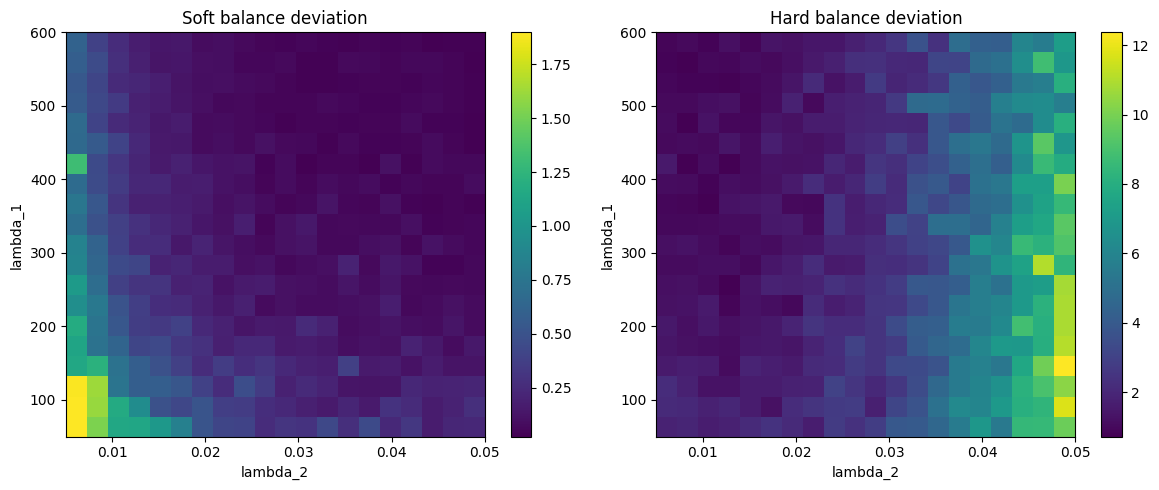


Top 5 parameter combinations (best soft balance):
lambda1=22.7632  lambda2=0.0500  soft_dev=0.023762  hard_dev=6.816932
lambda1=27.1579  lambda2=0.0453  soft_dev=0.027203  hard_dev=6.042351
lambda1=16.2673  lambda2=0.0382  soft_dev=0.027674  hard_dev=4.340169
lambda1=24.2105  lambda2=0.0500  soft_dev=0.027722  hard_dev=8.083174
lambda1=13.2382  lambda2=0.0311  soft_dev=0.028979  hard_dev=2.267296

Top 5 parameter combinations (best hard balance):
lambda1=3.0582  lambda2=0.0121  soft_dev=0.306707  hard_dev=0.718831
lambda1=5.1607  lambda2=0.0121  soft_dev=0.219456  hard_dev=0.730741
lambda1=3.5873  lambda2=0.0097  soft_dev=0.307377  hard_dev=0.731969
lambda1=4.2078  lambda2=0.0074  soft_dev=0.449112  hard_dev=0.737736
lambda1=3.1413  lambda2=0.0074  soft_dev=0.446978  hard_dev=0.755764

Top 5 parameter combinations (best combined):
lambda1=5.1607  lambda2=0.0121  soft_dev=0.219456  hard_dev=0.730741
lambda1=8.6842  lambda2=0.0145  soft_dev=0.137813  hard_dev=0.872273
lambda1=3.0582  la

(array([[1.8959347 , 1.53126742, 1.14942504, 1.13576518, 1.02321749,
         0.84101209, 0.51347983, 0.41330863, 0.40125517, 0.25931952,
         0.3116735 , 0.29493122, 0.43234487, 0.27428023, 0.44429341,
         0.24194916, 0.32846939, 0.16681342, 0.22782049, 0.23020642],
        [1.89738776, 1.60655171, 1.16655221, 0.93682887, 0.48862303,
         0.42407438, 0.50961067, 0.37177306, 0.35961159, 0.26949466,
         0.23869754, 0.18782085, 0.16159123, 0.2182746 , 0.15731486,
         0.30120064, 0.25660146, 0.16345599, 0.20425403, 0.27740554],
        [1.88948261, 1.62021602, 0.74354442, 0.5807607 , 0.58269067,
         0.52516732, 0.38566637, 0.26234855, 0.46512203, 0.35080629,
         0.19595841, 0.2469654 , 0.20951287, 0.13260065, 0.12058797,
         0.13098922, 0.22930566, 0.20161893, 0.20958555, 0.21427266],
        [1.14927835, 1.21835559, 0.72685906, 0.58210133, 0.49030224,
         0.375804  , 0.25971994, 0.35854194, 0.27045745, 0.31350877,
         0.23640266, 0.19884257

In [96]:
evaluate_lambda_grid2(
    pop.coords,
    pop.inclusions,
    K=n,
    alpha_range=(50, 600),
    lambda2_range=(0.005, 0.05),
    n_alpha=20,
    n_lambda2=20,
    random_state=42
)

In [5]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.special import logsumexp


class SinkhornBalancedKMeans:

    def __init__(
        self,
        n_clusters,
        epsilon=0.05,
        max_iter=50,
        sinkhorn_iter=50,
        tol=1e-4,
        n_init=10,
        random_state=None,
    ):
        self.K = n_clusters
        self.epsilon = epsilon
        self.max_iter = max_iter
        self.sinkhorn_iter = sinkhorn_iter
        self.tol = tol
        self.n_init = n_init
        self.random_state = random_state


    def _compute_distances(self, X, centers):
        return cdist(X, centers, metric="sqeuclidean")


    def _weighted_kmeanspp(self, X, pi, rng):

        N, D = X.shape
        K = self.K

        centers = np.empty((K, D))

        idx = rng.integers(N)
        centers[0] = X[idx]

        closest_dist = np.sum((X - centers[0]) ** 2, axis=1)

        for k in range(1, K):

            probs = pi * closest_dist
            probs /= probs.sum()

            idx = rng.choice(N, p=probs)
            centers[k] = X[idx]

            new_dist = np.sum((X - centers[k]) ** 2, axis=1)
            closest_dist = np.minimum(closest_dist, new_dist)

        return centers


    def _sinkhorn_log(self, C, pi, b, f, g):

        eps = self.epsilon

        for _ in range(self.sinkhorn_iter):

            tmp = (g[None, :] - C) / eps
            f = eps * (np.log(pi) - logsumexp(tmp, axis=1))

            tmp = (f[:, None] - C) / eps
            g = eps * (np.log(b) - logsumexp(tmp, axis=0))

        return f, g


    def _hard_objective(self, X, centers, labels, pi):

        d = np.sum((X - centers[labels]) ** 2, axis=1)
        return np.sum(pi * d)


    def _fit_single(self, X, pi, rng):

        N, D = X.shape
        K = self.K

        b = np.ones(K)

        centers = self._weighted_kmeanspp(X, pi, rng)

        f = np.zeros(N)
        g = np.zeros(K)

        for _ in range(self.max_iter):

            C = self._compute_distances(X, centers)

            C = C / (np.median(C) + 1e-12)

            f, g = self._sinkhorn_log(C, pi, b, f, g)

            P = np.exp((f[:, None] + g[None, :] - C) / self.epsilon)

            new_centers = P.T @ X

            shift = np.linalg.norm(new_centers - centers)

            centers = new_centers

            if shift < self.tol:
                break

        R = P / pi[:, None]
        labels = np.argmax(R, axis=1)

        obj = self._hard_objective(X, centers, labels, pi)

        return centers, P, R, labels, obj


    def fit(self, X, pi=None):

        rng = np.random.default_rng(self.random_state)

        N, D = X.shape
        K = self.K

        if pi is None:
            pi = np.ones(N) * (K / N)

        assert np.isclose(pi.sum(), K)

        best_obj = np.inf
        best_state = None

        for _ in range(self.n_init):

            centers, P, R, labels, obj = self._fit_single(X, pi, rng)

            if obj < best_obj:
                best_obj = obj
                best_state = (centers, P, R, labels)

        self.centroids, self.transport_plan, self.assignments, self.labels = best_state
        self.objective_ = best_obj

        return self


In [37]:
model = SinkhornBalancedKMeans(
    n_clusters=n,
    epsilon=0.01,
    max_iter=50,
    sinkhorn_iter=50,
    tol=1e-4,
    n_init=10,
)

model.fit(pop.coords, pop.inclusions)

In [38]:
deviation = 0
for i in range(n):
    hard = float(pop.inclusions[model.labels == i].sum())
    p = model.assignments[:, i] * pop.inclusions
    soft = float(p.sum())
    deviation += abs(hard - 1)
    print(f'Cluster {i+1}: soft={soft:4f} - hard={hard:4f}')

print(f'\nTotal Deviation of Hard: {deviation:.4f}')

Cluster 1: soft=1.000000 - hard=1.028550
Cluster 2: soft=1.000000 - hard=0.996663
Cluster 3: soft=1.000000 - hard=1.010604
Cluster 4: soft=1.000000 - hard=1.012325
Cluster 5: soft=1.000000 - hard=0.993895
Cluster 6: soft=1.000000 - hard=0.979319
Cluster 7: soft=1.000000 - hard=0.969648
Cluster 8: soft=1.000000 - hard=1.010964
Cluster 9: soft=1.000000 - hard=1.013086
Cluster 10: soft=1.000000 - hard=0.984946

Total Deviation of Hard: 0.1511


/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T/ipykernel_3717/1218941298.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", k)


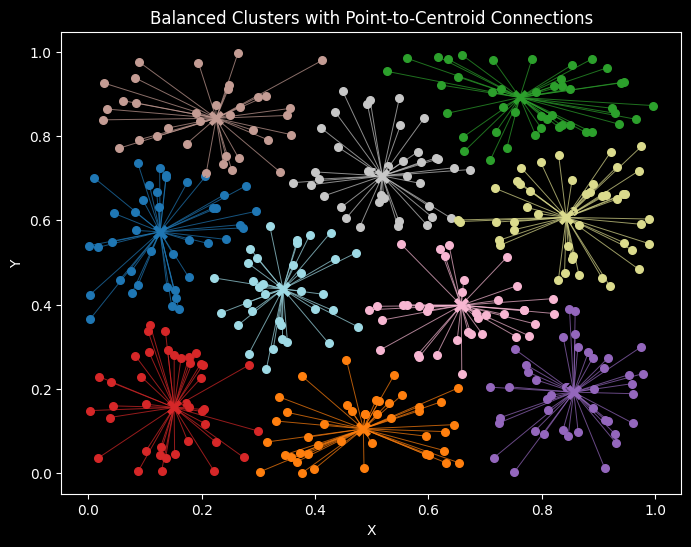

In [39]:
plot_clusters_with_lines(coords, model.labels, model.centroids)